# Step 14 — heatmap: consensus matrices, one row of panels per site

**Data type: RNA_array** (GSE65391). **Reads:** `step12_site_{A,B,C}.rds`, `step12_consensus.rds`,
`step13_site_{A,B,C}.rds`. **Writes:** `figures/fig14_RNA_array_consensus_matrices.png`.

Each panel is one site's discovery patients × the same patients. A cell is the share of subsampled
federated k-means runs in which the two patients landed in the same cluster: dark blue always, white
never. Clean blocks on the diagonal, white between them, mean a stable partition. A site can draw only
its own pairs, so there is one row of panels per site. Patients are ordered within each panel by
clustering on that panel's consensus. The top bar is each patient's final endotype (step 13), so you
can see how the chosen groups split or merge as k changes.

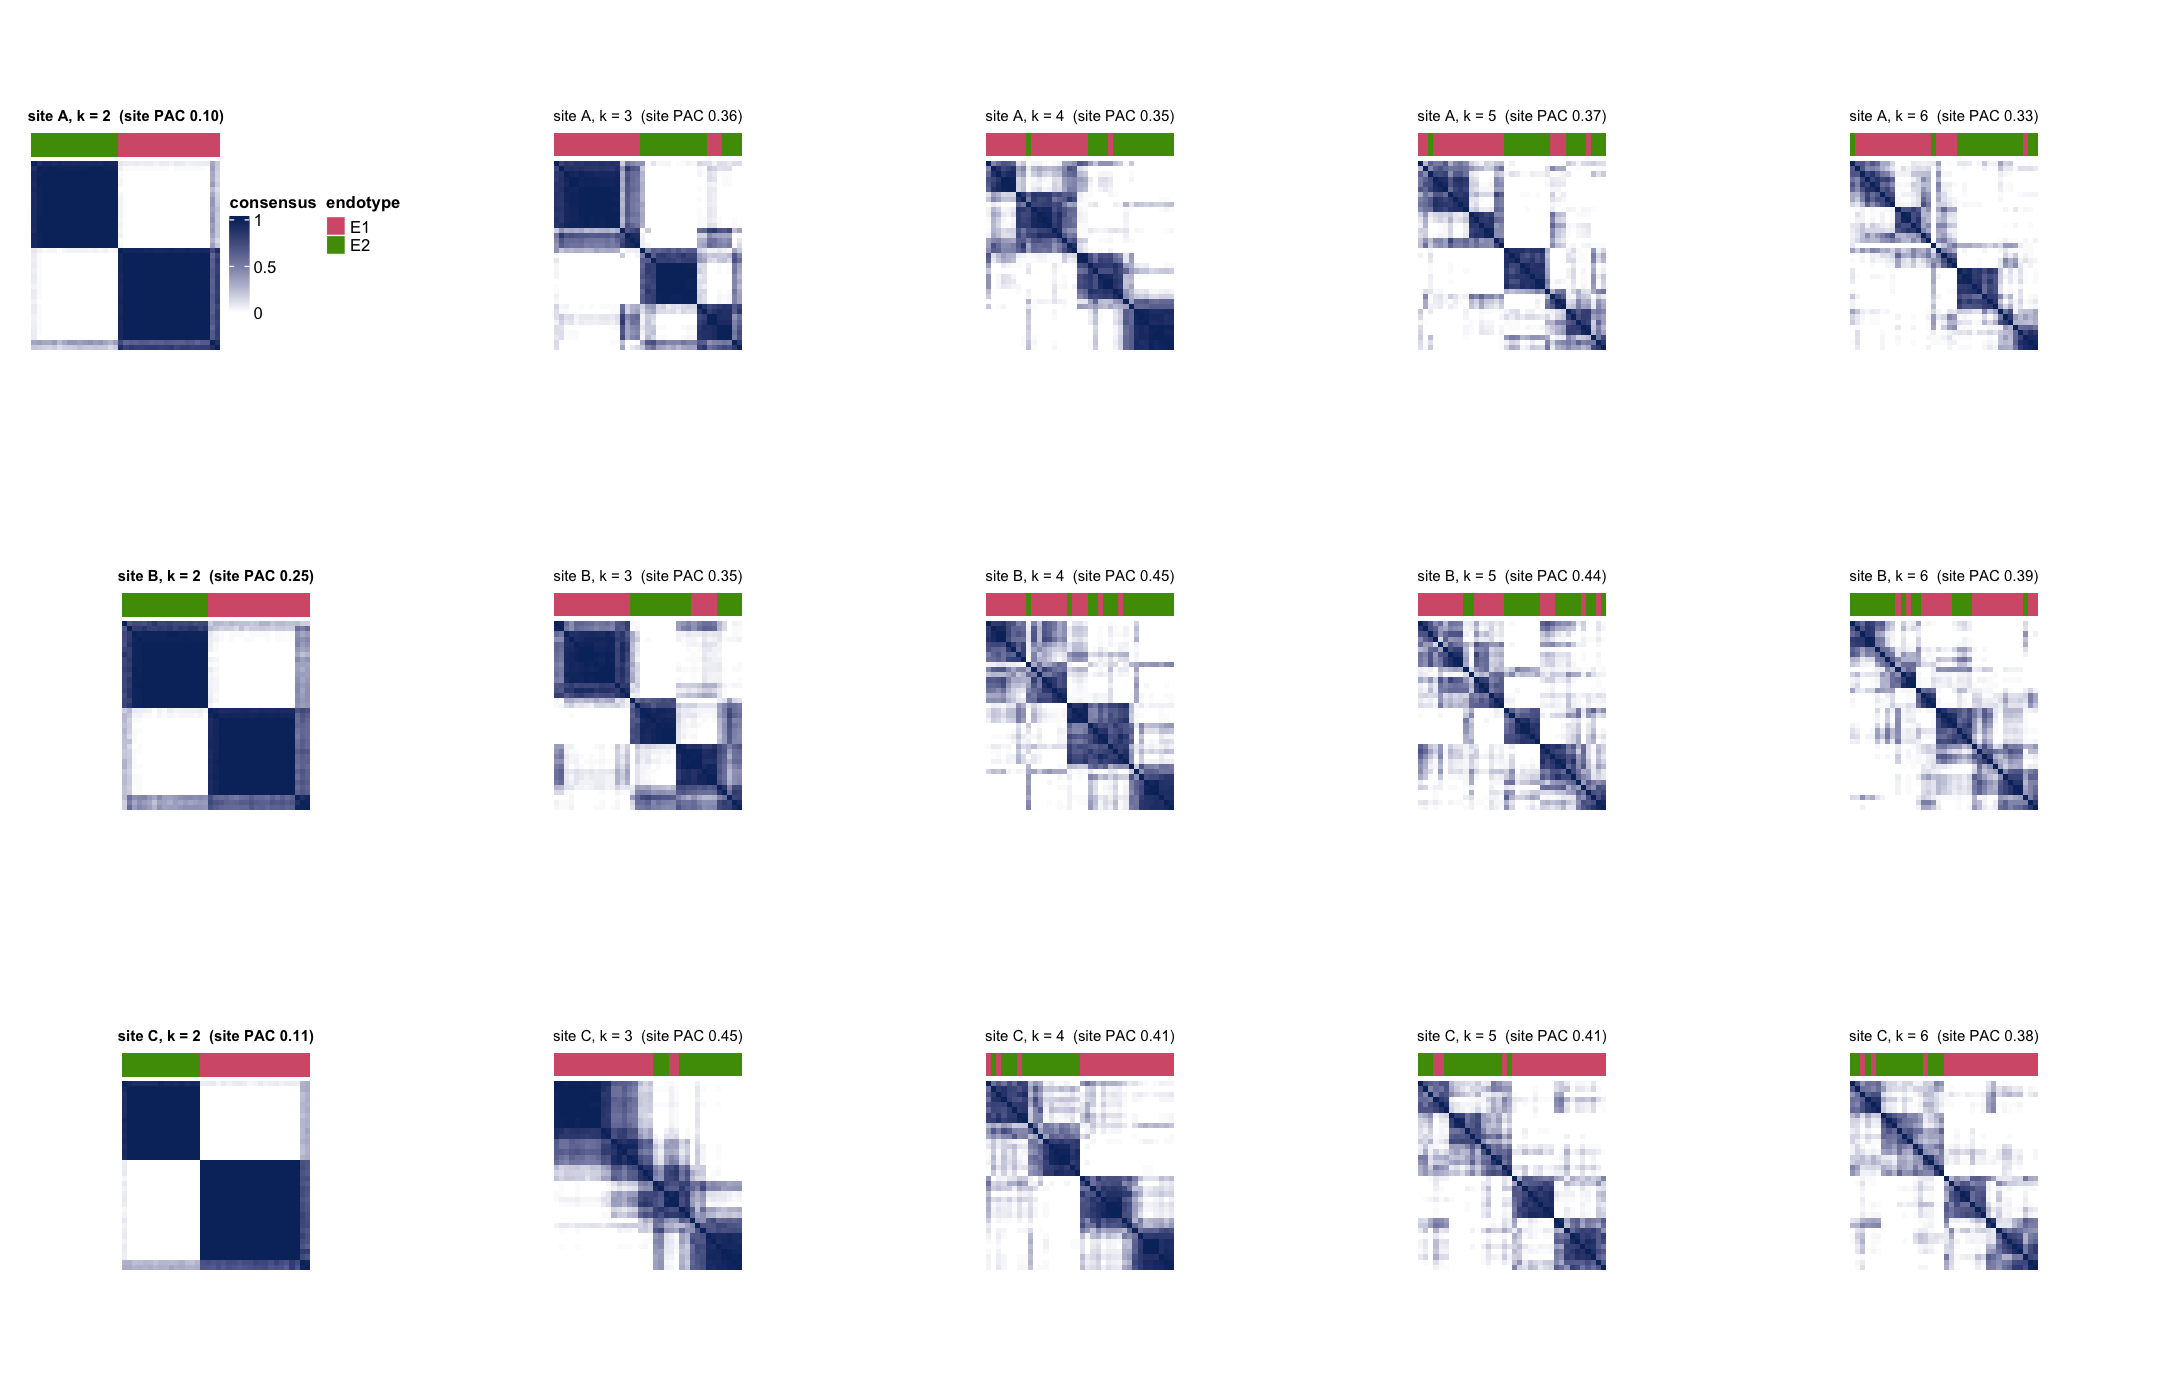

In [1]:
source("../src/paths.R")
source("../src/figures.R")
cons <- readRDS(art("step12_consensus.rds"))
K    <- cons$k
EN_COL <- endotype_colours(paste0("E", seq_len(K)))
panel <- function(s, k) {
  C  <- readRDS(site_file("12", s))[[as.character(k)]]
  m  <- readRDS(site_file("13", s))$meta
  hc <- hclust(as.dist(1 - C), method = "average")
  first <- s == SITES[1] && k == min(cons$pac$k)
  Heatmap(C, name = "consensus", col = colorRamp2(c(0, 1), c("white", "#08306B")),
          cluster_rows = hc, cluster_columns = hc, show_row_dend = FALSE, show_column_dend = FALSE,
          show_row_names = FALSE, show_column_names = FALSE,
          column_title = sprintf("site %s, k = %d  (site PAC %.2f)", s, k, cons$pac[cons$pac$k == k, paste0("pac_", s)]),
          column_title_gp = gpar(fontsize = 9, fontface = if (k == K) "bold" else "plain"),
          top_annotation = HeatmapAnnotation(endotype = m[rownames(C), "endotype_kmeans"],
                                             col = list(endotype = EN_COL), show_annotation_name = FALSE,
                                             show_legend = first),
          show_heatmap_legend = first, width = unit(40, "mm"), height = unit(40, "mm"))
}
draw_grid <- function() {
  ks <- cons$pac$k
  grid.newpage()
  pushViewport(viewport(layout = grid.layout(length(SITES), length(ks))))
  for (i in seq_along(SITES)) for (j in seq_along(ks)) {
    pushViewport(viewport(layout.pos.row = i, layout.pos.col = j))
    draw(panel(SITES[i], ks[j]), newpage = FALSE)
    popViewport()
  }
  popViewport()
}
png(fig("fig14_RNA_array_consensus_matrices.png"), width = 2600, height = 1650, res = 150); draw_grid(); invisible(dev.off())
options(repr.plot.width = 18, repr.plot.height = 11.5); draw_grid()

## Findings

At k = 2 every site shows two clean blocks with white between them. From k = 3 upwards the blocks
break into pieces with grey between them at every site. The data support two groups, and each site
sees this in its own patients.